# Data Shape

In [3]:
# 1. Import libraries
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [4]:
# 2. Load data (Total, Train, Val, Test)
DATA_DIR = os.getcwd()
SHAPE_DIR = os.path.join(DATA_DIR, "shape")

if not os.path.exists(SHAPE_DIR):
    os.makedirs(SHAPE_DIR)
    print(f"✅ Created output directory: {SHAPE_DIR}")

# Use glob to automatically find files matching the patterns without hardcoding the exact numbers
try:
    total_file = glob.glob(os.path.join(DATA_DIR, "total_*.csv"))[0]
    train_file = glob.glob(os.path.join(DATA_DIR, "train_*.csv"))[0]
    val_file = glob.glob(os.path.join(DATA_DIR, "val_*.csv"))[0]
    test_file = glob.glob(os.path.join(DATA_DIR, "test_*.csv"))[0]

    # Load datasets
    df_total = pd.read_csv(total_file)
    df_train = pd.read_csv(train_file)
    df_val = pd.read_csv(val_file)
    df_test = pd.read_csv(test_file)

    # Keep one fixed category order based on the Total dataset
    category_order_total = df_total['major_code'].value_counts().index.tolist()

    print(f"\n✅ Successfully Loaded Data")
    print(f"- Target Files Found:")
    print(f"  * {os.path.basename(total_file)}")
    print(f"  * {os.path.basename(train_file)}")
    print(f"  * {os.path.basename(val_file)}")
    print(f"  * {os.path.basename(test_file)}")
    print("-" * 30)
    print(f"- Total: {len(df_total)}")
    print(f"- Train: {len(df_train)}")
    print(f"- Val:   {len(df_val)}")
    print(f"- Test:  {len(df_test)}")

except IndexError:
    print("❌ Error: Missing required CSV files (total_*.csv, train_*.csv, val_*.csv, test_*.csv) in the 'data' directory. Please check if the preprocessing step was completed successfully.")

✅ Created output directory: c:\Users\Minkyu Ham\Desktop\stat359\student\final_project\clinical_note_icd_llm\data\shape

✅ Successfully Loaded Data
- Target Files Found:
  * total_30_9987.csv
  * train_30_7989.csv
  * val_30_999.csv
  * test_30_999.csv
------------------------------
- Total: 9987
- Train: 7989
- Val:   999
- Test:  999


In [5]:
# 3. Data distribution function
def get_distribution(df, split_name, category_order=None):
    """
    Calculates distribution, displays a horizontal dataframe,
    and returns the vertical dataframe for saving.
    """
    total_samples = len(df)
    counts = df['major_code'].value_counts()

    # Reindex to keep a fixed order across all splits
    if category_order is not None:
        counts = counts.reindex(category_order, fill_value=0)

    # Create a vertical DataFrame (for saving)
    dist_df = pd.DataFrame({
        'Category': counts.index,
        'Count': counts.values.astype(int)  # Keep exact integers
    })
    dist_df['Ratio (%)'] = (dist_df['Count'] / total_samples * 100).round(2)

    # Create a horizontal DataFrame for display
    display_df = dist_df.copy()
    display_df['Count'] = display_df['Count'].astype(str)

    horizontal_df = display_df.set_index('Category').T

    print(f"\n📊 [{split_name} Dataset] Class Distribution (Total: {total_samples})")
    display(horizontal_df)

    return dist_df

In [6]:
# 4. Plot function
def get_plot(dist_df, split_name, color_palette):
    """
    Creates a bar chart, displays it, and returns the Figure object.
    """
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Keep the x-axis order fixed to the given distribution order
    sns.barplot(
        data=dist_df,
        x='Category',
        y='Count',
        order=dist_df['Category'].tolist(),
        hue='Category',
        palette=color_palette,
        ax=ax,
        legend=False
    )
    
    # Add integer count annotations on top of bars
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8),
                    textcoords='offset points', fontsize=9)
    
    # Formatting
    ax.set_title(f'{split_name} Dataset Class Distribution', fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('ICD-10 Category (Top 30, fixed Total order)', fontsize=14, labelpad=10)
    ax.set_ylabel('Number of Samples', fontsize=14, labelpad=10)
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    
    plt.tight_layout()
    display(fig)
    
    return fig

In [7]:
# 5. Output save function (csv table, txt table, png plot)
def save_outputs(dist_df, fig, split_name):
    """
    Saves the distribution as a .csv file, a vertical .txt table, and the plot as a .png image.
    """
    # Save the distribution as a .csv file
    csv_path = os.path.join(SHAPE_DIR, f"{split_name.lower()}_dist.csv")
    dist_df.to_csv(csv_path, index=False, encoding='utf-8-sig')

    # Save the distribution as a .txt file (Vertical format)
    txt_path = os.path.join(SHAPE_DIR, f"{split_name.lower()}_dist.txt")
    with open(txt_path, "w", encoding='utf-8') as f:
        f.write(f"[{split_name} Dataset Distribution]\n")
        f.write("="*40 + "\n")
        f.write(dist_df.to_string(index=False))
        f.write("\n" + "="*40 + "\n")
    
    # Save the plot as a .png file
    plot_path = os.path.join(SHAPE_DIR, f"{split_name.lower()}_dist.png")
    fig.savefig(plot_path, dpi=300)
    
    # Close the figure to free up memory
    plt.close(fig)
    
    print(f"📁 Successfully saved Table (.csv, .txt) for {split_name}.")
    print(f"📁 Successfully saved Plot (.png) for {split_name}.")


📊 [Total Dataset] Class Distribution (Total: 9987)


Category,A41,I21,Z51,I25,I13,I63,E11,N17,K80,J18,...,L03,G40,M17,S82,K70,K85,I35,K92,M48,R10
Count,1037,576,519,499,458,423,393,375,349,329,...,242,241,233,225,220,213,212,207,200,199
Ratio (%),10.38,5.77,5.2,5.0,4.59,4.24,3.94,3.75,3.49,3.29,...,2.42,2.41,2.33,2.25,2.2,2.13,2.12,2.07,2.0,1.99


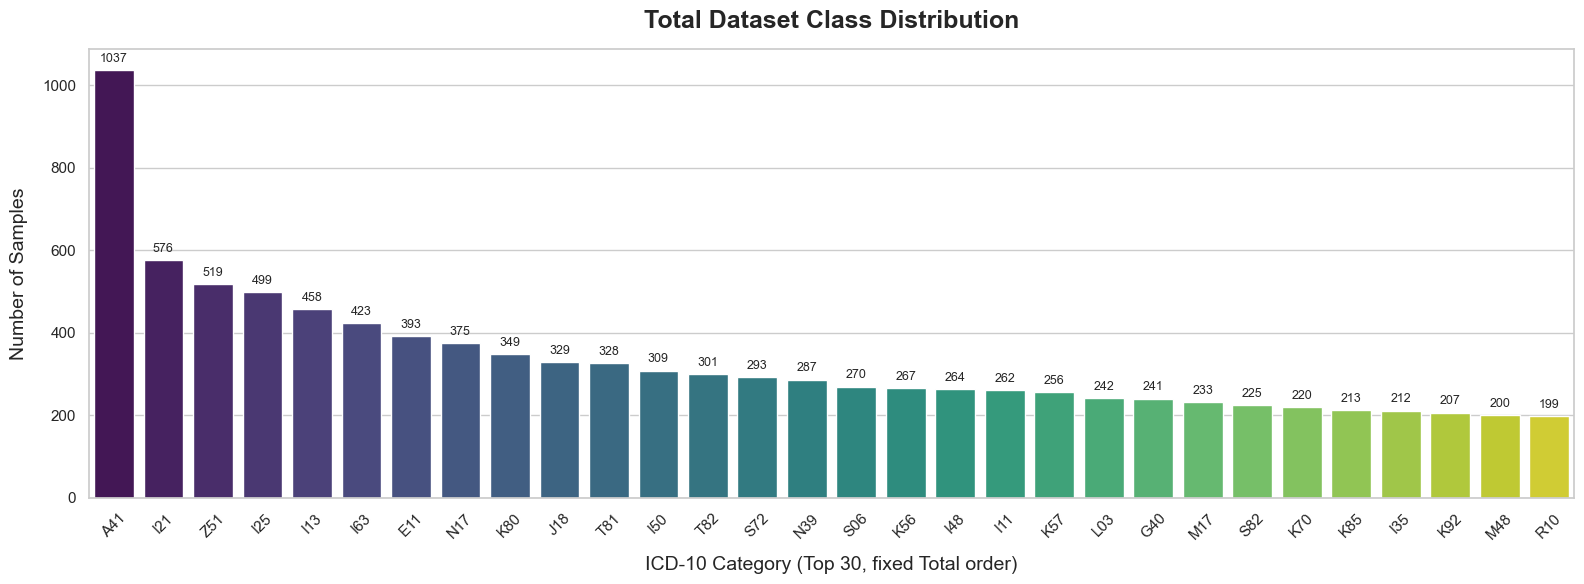

📁 Successfully saved Table (.csv, .txt) for Total.
📁 Successfully saved Plot (.png) for Total.


In [8]:
# 6. Check and save Total distribution
dist_total = get_distribution(df_total, "Total", category_order_total)
fig_total = get_plot(dist_total, "Total", "viridis")
save_outputs(dist_total, fig_total, "Total")


📊 [Train Dataset] Class Distribution (Total: 7989)


Category,A41,I21,Z51,I25,I13,I63,E11,N17,K80,J18,...,L03,G40,M17,S82,K70,K85,I35,K92,M48,R10
Count,830,461,415,399,366,338,314,300,279,263,...,194,193,186,180,176,170,170,166,160,159
Ratio (%),10.39,5.77,5.19,4.99,4.58,4.23,3.93,3.76,3.49,3.29,...,2.43,2.42,2.33,2.25,2.2,2.13,2.13,2.08,2.0,1.99


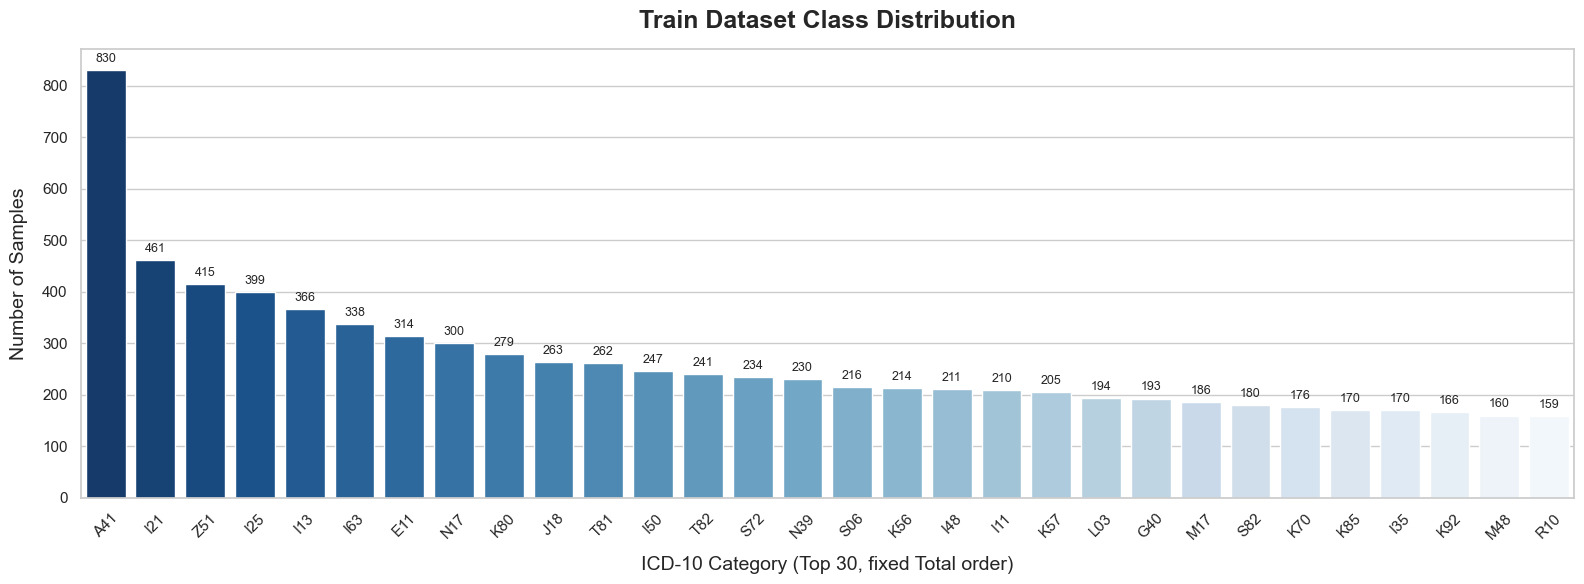

📁 Successfully saved Table (.csv, .txt) for Train.
📁 Successfully saved Plot (.png) for Train.


In [9]:
# 7. Check and save Train distribution
dist_train = get_distribution(df_train, "Train", category_order_total)
fig_train = get_plot(dist_train, "Train", "Blues_r")
save_outputs(dist_train, fig_train, "Train")


📊 [Validation Dataset] Class Distribution (Total: 999)


Category,A41,I21,Z51,I25,I13,I63,E11,N17,K80,J18,...,L03,G40,M17,S82,K70,K85,I35,K92,M48,R10
Count,103,58,52,50,46,42,40,38,35,33,...,24,24,24,22,22,21,21,21,20,20
Ratio (%),10.31,5.81,5.21,5.01,4.6,4.2,4.0,3.8,3.5,3.3,...,2.4,2.4,2.4,2.2,2.2,2.1,2.1,2.1,2.0,2.0


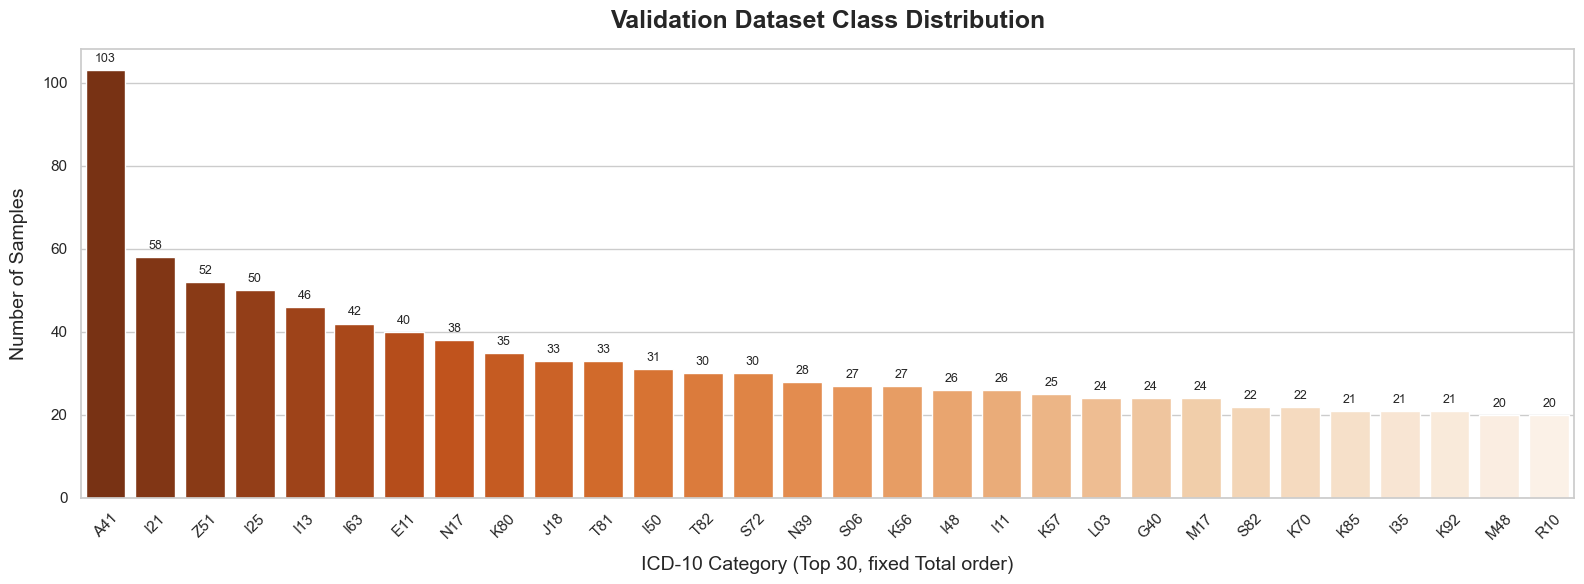

📁 Successfully saved Table (.csv, .txt) for Validation.
📁 Successfully saved Plot (.png) for Validation.


In [10]:
# 8. Check and save Val distribution
dist_val = get_distribution(df_val, "Validation", category_order_total)
fig_val = get_plot(dist_val, "Validation", "Oranges_r")
save_outputs(dist_val, fig_val, "Validation")


📊 [Test Dataset] Class Distribution (Total: 999)


Category,A41,I21,Z51,I25,I13,I63,E11,N17,K80,J18,...,L03,G40,M17,S82,K70,K85,I35,K92,M48,R10
Count,104,57,52,50,46,43,39,37,35,33,...,24,24,23,23,22,22,21,20,20,20
Ratio (%),10.41,5.71,5.21,5.01,4.6,4.3,3.9,3.7,3.5,3.3,...,2.4,2.4,2.3,2.3,2.2,2.2,2.1,2.0,2.0,2.0


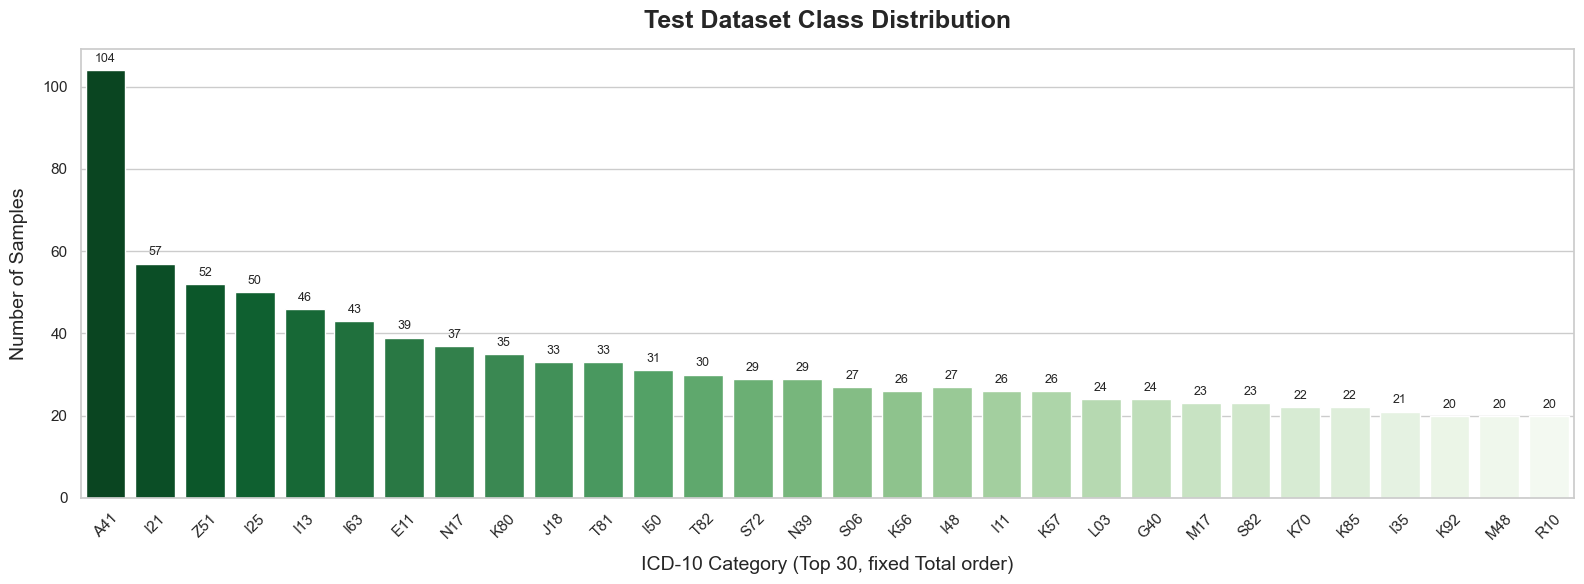

📁 Successfully saved Table (.csv, .txt) for Test.
📁 Successfully saved Plot (.png) for Test.


In [11]:
# 9. Check and save Test distribution
dist_test = get_distribution(df_test, "Test", category_order_total)
fig_test = get_plot(dist_test, "Test", "Greens_r")
save_outputs(dist_test, fig_test, "Test")

In [12]:
# 10. Additional checks before modeling

def get_ratio_comparison(dist_total, dist_train, dist_val, dist_test):
    """Compare class ratios across splits using the fixed Total order."""
    ratio_compare = dist_total[['Category', 'Ratio (%)']].rename(columns={'Ratio (%)': 'Total Ratio (%)'})
    ratio_compare = ratio_compare.merge(
        dist_train[['Category', 'Ratio (%)']].rename(columns={'Ratio (%)': 'Train Ratio (%)'}),
        on='Category', how='left'
    )
    ratio_compare = ratio_compare.merge(
        dist_val[['Category', 'Ratio (%)']].rename(columns={'Ratio (%)': 'Validation Ratio (%)'}),
        on='Category', how='left'
    )
    ratio_compare = ratio_compare.merge(
        dist_test[['Category', 'Ratio (%)']].rename(columns={'Ratio (%)': 'Test Ratio (%)'}),
        on='Category', how='left'
    )

    ratio_compare['Train Abs Diff (%p)'] = (ratio_compare['Train Ratio (%)'] - ratio_compare['Total Ratio (%)']).abs().round(2)
    ratio_compare['Validation Abs Diff (%p)'] = (ratio_compare['Validation Ratio (%)'] - ratio_compare['Total Ratio (%)']).abs().round(2)
    ratio_compare['Test Abs Diff (%p)'] = (ratio_compare['Test Ratio (%)'] - ratio_compare['Total Ratio (%)']).abs().round(2)
    return ratio_compare


def get_ratio_summary(ratio_compare):
    """Summarize how far each split moved from the Total distribution."""
    return pd.DataFrame({
        'Split': ['Train', 'Validation', 'Test'],
        'Max Abs Diff (%p)': [
            ratio_compare['Train Abs Diff (%p)'].max(),
            ratio_compare['Validation Abs Diff (%p)'].max(),
            ratio_compare['Test Abs Diff (%p)'].max(),
        ],
        'Mean Abs Diff (%p)': [
            ratio_compare['Train Abs Diff (%p)'].mean().round(3),
            ratio_compare['Validation Abs Diff (%p)'].mean().round(3),
            ratio_compare['Test Abs Diff (%p)'].mean().round(3),
        ]
    })


def get_length_stats(df, split_name, text_col='filtered_text'):
    """Check text length distribution as a quick proxy before tokenization."""
    text_series = df[text_col].fillna('').astype(str)
    char_len = text_series.str.len()
    word_len = text_series.str.split().str.len()

    return pd.DataFrame([{
        'Split': split_name,
        'Samples': len(df),
        'Mean Char Len': round(char_len.mean(), 1),
        'Median Char Len': int(char_len.median()),
        'P90 Char Len': int(char_len.quantile(0.90)),
        'P95 Char Len': int(char_len.quantile(0.95)),
        'Max Char Len': int(char_len.max()),
        'Mean Word Len': round(word_len.mean(), 1),
        'Median Word Len': int(word_len.median()),
        'P90 Word Len': int(word_len.quantile(0.90)),
        'P95 Word Len': int(word_len.quantile(0.95)),
        'Max Word Len': int(word_len.max())
    }])


def get_basic_sanity(df, split_name):
    """Check missing, empty, and duplicate text counts."""
    text_series = df['filtered_text'].fillna('').astype(str).str.strip()
    return pd.DataFrame([{
        'Split': split_name,
        'Rows': len(df),
        'Missing filtered_text': int(df['filtered_text'].isna().sum()),
        'Empty filtered_text': int((text_series == '').sum()),
        'Missing major_code': int(df['major_code'].isna().sum()),
        'Duplicate filtered_text': int(text_series.duplicated().sum())
    }])


def get_overlap_count(df_left, df_right, left_name, right_name, text_col='filtered_text'):
    """Check exact text overlap across splits to catch possible leakage."""
    left_set = set(df_left[text_col].fillna('').astype(str).str.strip())
    right_set = set(df_right[text_col].fillna('').astype(str).str.strip())
    left_set.discard('')
    right_set.discard('')
    return {
        'Pair': f'{left_name} vs {right_name}',
        'Exact Overlap Count': len(left_set & right_set)
    }


# Ratio comparison
ratio_compare = get_ratio_comparison(dist_total, dist_train, dist_val, dist_test)
ratio_summary = get_ratio_summary(ratio_compare)

print("\n📌 Ratio Comparison by Category (fixed Total order)")
display(ratio_compare)
print("\n📌 Ratio Drift Summary")
display(ratio_summary)

ratio_compare.to_csv(os.path.join(SHAPE_DIR, 'ratio_comparison_vs_total.csv'), index=False, encoding='utf-8-sig')
ratio_summary.to_csv(os.path.join(SHAPE_DIR, 'ratio_summary_vs_total.csv'), index=False, encoding='utf-8-sig')


# Text length summary
length_stats = pd.concat([
    get_length_stats(df_total, 'Total'),
    get_length_stats(df_train, 'Train'),
    get_length_stats(df_val, 'Validation'),
    get_length_stats(df_test, 'Test')
], ignore_index=True)

print("\n📌 filtered_text Length Summary")
display(length_stats)
length_stats.to_csv(os.path.join(SHAPE_DIR, 'filtered_text_length_summary.csv'), index=False, encoding='utf-8-sig')


# Basic sanity summary
sanity_stats = pd.concat([
    get_basic_sanity(df_total, 'Total'),
    get_basic_sanity(df_train, 'Train'),
    get_basic_sanity(df_val, 'Validation'),
    get_basic_sanity(df_test, 'Test')
], ignore_index=True)

print("\n📌 Basic Sanity Check")
display(sanity_stats)
sanity_stats.to_csv(os.path.join(SHAPE_DIR, 'basic_sanity_check.csv'), index=False, encoding='utf-8-sig')


# Exact overlap check
overlap_stats = pd.DataFrame([
    get_overlap_count(df_train, df_val, 'Train', 'Validation'),
    get_overlap_count(df_train, df_test, 'Train', 'Test'),
    get_overlap_count(df_val, df_test, 'Validation', 'Test')
])

print("\n📌 Exact filtered_text Overlap Across Splits")
display(overlap_stats)
overlap_stats.to_csv(os.path.join(SHAPE_DIR, 'split_text_overlap_check.csv'), index=False, encoding='utf-8-sig')

if overlap_stats['Exact Overlap Count'].sum() > 0:
    print("⚠️ Warning: Exact text overlap was found across splits. Please inspect possible data leakage.")
else:
    print("✅ No exact filtered_text overlap found across Train/Validation/Test.")


📌 Ratio Comparison by Category (fixed Total order)


,Category,Total Ratio (%),Train Ratio (%),Validation Ratio (%),Test Ratio (%),Train Abs Diff (%p),Validation Abs Diff (%p),Test Abs Diff (%p)
0,A41,10.38,10.39,10.31,10.41,0.01,0.07,0.03
1,I21,5.77,5.77,5.81,5.71,0.00,0.04,0.06
2,Z51,5.20,5.19,5.21,5.21,0.01,0.01,0.01
3,I25,5.00,4.99,5.01,5.01,0.01,0.01,0.01
4,I13,4.59,4.58,4.60,4.60,0.01,0.01,0.01
5,I63,4.24,4.23,4.20,4.30,0.01,0.04,0.06
6,E11,3.94,3.93,4.00,3.90,0.01,0.06,0.04
7,N17,3.75,3.76,3.80,3.70,0.01,0.05,0.05
8,K80,3.49,3.49,3.50,3.50,0.00,0.01,0.01
9,J18,3.29,3.29,3.30,3.30,0.00,0.01,0.01



📌 Ratio Drift Summary


,Split,Max Abs Diff (%p),Mean Abs Diff (%p)
0,Train,0.01,0.005
1,Validation,0.07,0.029
2,Test,0.07,0.029



📌 filtered_text Length Summary


...


📌 Basic Sanity Check


,Split,Rows,Missing filtered_text,Empty filtered_text,Missing major_code,Duplicate filtered_text
0,Total,9987,0,0,0,0
1,Train,7989,0,0,0,0
2,Validation,999,0,0,0,0
3,Test,999,0,0,0,0



📌 Exact filtered_text Overlap Across Splits


,Pair,Exact Overlap Count
0,Train vs Validation,0
1,Train vs Test,0
2,Validation vs Test,0


✅ No exact filtered_text overlap found across Train/Validation/Test.
